# Grammar

``` 
e :       e '↔' e
         | e '→' e
         | e '∨' e
         | e '∧' e
         | '(' e ')'
         | '¬' e
         | '⊤'
         | '⊥'
         | VAR
         ;
         
```

# Scanner

In [1]:
# Logic Symbols 
'↔ → ∧ ∨ ¬ ⊤ ⊥'

'↔ → ∧ ∨ ¬ ⊤ ⊥'

In [2]:
import ply.lex as lex

In [3]:
tokens = ['VAR']

In [4]:
def t_VAR(t):
    r'[a-zA-Z][a-zA-Z0-9_]*'
    return t

In [5]:
literals = ['↔', '→', '∨', '∧', '¬', '(', ')', '⊤', '⊥']

In [6]:
t_ignore = ' \t'

In [7]:
def t_newline(t):
    r'\n+'
    t.lexer.lineno += t.value.count('\n')

In [8]:
def t_error(t):
    print(f"Illegal character '{t.value[0]}' at character number {t.lexer.lexpos} in line {t.lexer.lineno}.")
    t.lexer.skip(1)

In [9]:
__file__ = 'main'

In [10]:
lexer = lex.lex()

# Parser

In [11]:
import ply.yacc as yacc

In [12]:
precedence = ( ('nonassoc', '↔' ),
               ('right', '→'),
               ('left', '∨'),
               ('left', '∧'),
               ('right', '¬')
             )

In [13]:
def p_e_equiv(p):
    "e : e '↔' e"
    p[0] = ('↔', p[1], p[3])
    
def p_e_implic(p):
    "e : e '→' e"
    p[0] = ('→', p[1], p[3])
    
    
def p_e_disj(p):
    "e : e '∨' e"
    p[0] = ('∨', p[1], p[3])
    
    
def p_e_conj(p):
    "e : e '∧' e"
    p[0] = ('∧', p[1], p[3])
    
def p_e_neg(p):
    "e : '¬' e"
    p[0] = ('¬', p[2])
    
def p_e_paren(p):
    "e : '(' e ')'"
    p[0] = p[2]
    
def p_e_id(p):
    "e : VAR"
    p[0] = p[1]
    
def p_e_true(p):
    "e : '⊤'"
    p[0] = p[1]
    
def p_e_false(p):
    "e : '⊥'"
    p[0] = p[1]

In [14]:
def p_error(p):
    if p:
        print(f"Syntax error at character number {p.lexer.lexpos} at token '{p.value}' in line {p.lexer.lineno}.")
    else:
        print('Syntax error at end of input.')

In [15]:
yacc.yacc(write_tables=False, debug=True);

Generating LALR tables


In [16]:
!cat parser.out

Created by PLY version 3.11 (http://www.dabeaz.com/ply)

Grammar

Rule 0     S' -> e
Rule 1     e -> e ↔ e
Rule 2     e -> e → e
Rule 3     e -> e ∨ e
Rule 4     e -> e ∧ e
Rule 5     e -> ¬ e
Rule 6     e -> ( e )
Rule 7     e -> VAR
Rule 8     e -> ⊤
Rule 9     e -> ⊥

Terminals, with rules where they appear

(                    : 6
)                    : 6
VAR                  : 7
error                : 
¬                    : 5
→                    : 2
↔                    : 1
∧                    : 4
∨                    : 3
⊤                    : 8
⊥                    : 9

Nonterminals, with rules where they appear

e                    : 1 1 2 2 3 3 4 4 5 6 0

Parsing method: LALR

state 0

    (0) S' -> . e
    (1) e -> . e ↔ e
    (2) e -> . e → e
    (3) e -> . e ∨ e
    (4) e -> . e ∧ e
    (5) e -> . ¬ e
    (6) e -> . ( e )
    (7) e -> . VAR
    (8) e -> . ⊤
    (9) e -> . ⊥

    ¬               shift and go to state 2
    (               shift and go to state 3
    VAR

In [17]:
def test(s):
    t = yacc.parse(s)
    d = tuple2dot(t)
    display(d)
    return t

In [18]:
%run ../AST2Dot.ipynb

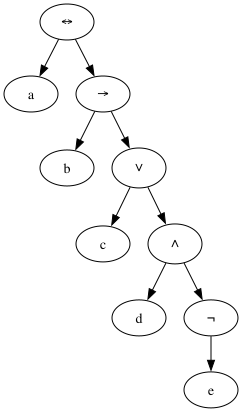

('↔', 'a', ('→', 'b', ('∨', 'c', ('∧', 'd', ('¬', 'e')))))

In [19]:
test('a ↔ b → c ∨ d ∧ ¬e')

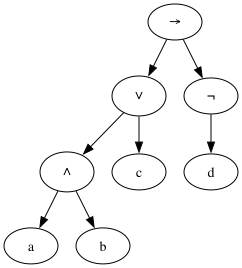

('→', ('∨', ('∧', 'a', 'b'), 'c'), ('¬', 'd'))

In [20]:
test('a ∧ b ∨ c → ¬d')

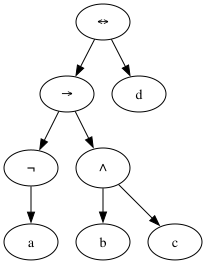

('↔', ('→', ('¬', 'a'), ('∧', 'b', 'c')), 'd')

In [21]:
test('¬a → b ∧ c ↔ d')

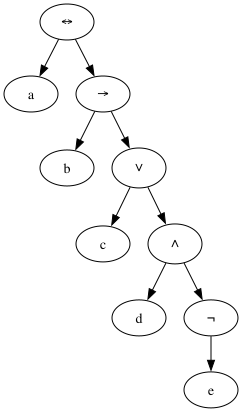

('↔', 'a', ('→', 'b', ('∨', 'c', ('∧', 'd', ('¬', 'e')))))

In [22]:
test('a ↔ b → c ∨ d ∧ ¬e')

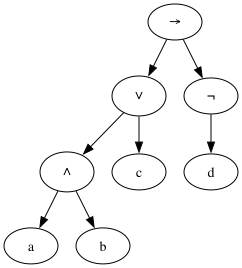

('→', ('∨', ('∧', 'a', 'b'), 'c'), ('¬', 'd'))

In [23]:
test('a ∧ b ∨ c → ¬d')

$\leftrightarrow$, $\rightarrow$, $\wedge$, $\vee$, $\neg$, $\top$, $\bot$

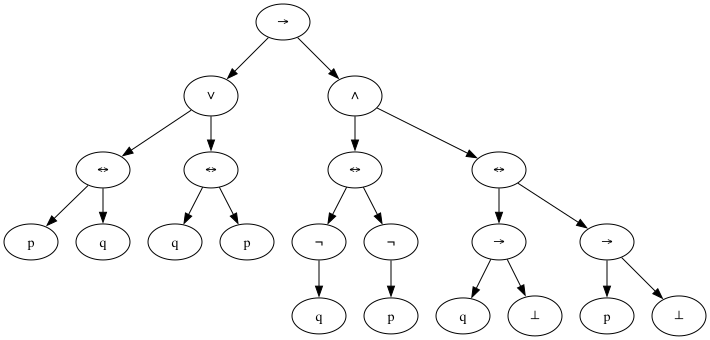

('→',
 ('∨', ('↔', 'p', 'q'), ('↔', 'q', 'p')),
 ('∧', ('↔', ('¬', 'q'), ('¬', 'p')), ('↔', ('→', 'q', '⊥'), ('→', 'p', '⊥'))))

In [24]:
test('(p ↔ q) ∨ (q ↔ p) → (¬q ↔ ¬p) ∧ (q → ⊥ ↔ p → ⊥)')

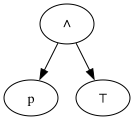

('∧', 'p', '⊤')

In [25]:
test('p ∧ ⊤')

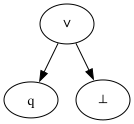

('∨', 'q', '⊥')

In [26]:
test('q ∨ ⊥')

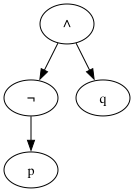

('∧', ('¬', 'p'), 'q')

In [27]:
test('¬p ∧ q')

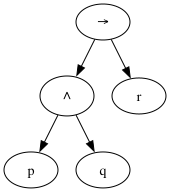

('→', ('∧', 'p', 'q'), 'r')

In [28]:
test('p ∧ q → r')

Implication is right-associative.

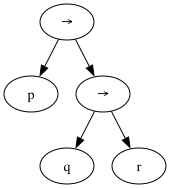

('→', 'p', ('→', 'q', 'r'))

In [29]:
test('p → q → r')

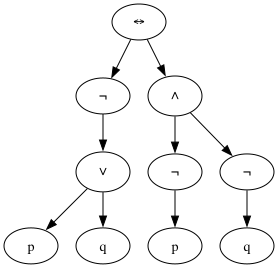

('↔', ('¬', ('∨', 'p', 'q')), ('∧', ('¬', 'p'), ('¬', 'q')))

In [30]:
test('¬(p ∨ q) ↔ ¬p ∧ ¬q')

Negation is right associative.

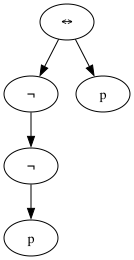

('↔', ('¬', ('¬', 'p')), 'p')

In [31]:
test('¬¬p ↔ p')

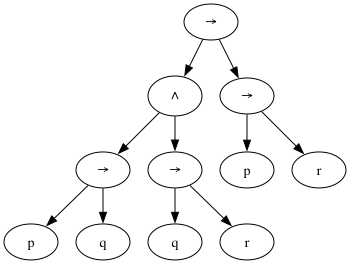

('→', ('∧', ('→', 'p', 'q'), ('→', 'q', 'r')), ('→', 'p', 'r'))

In [32]:
test('(p → q) ∧ (q → r) → p → r')

`∧` binds stronger than `∨`.

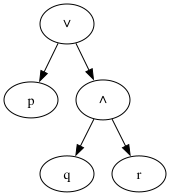

('∨', 'p', ('∧', 'q', 'r'))

In [33]:
test('p ∨ q ∧ r')

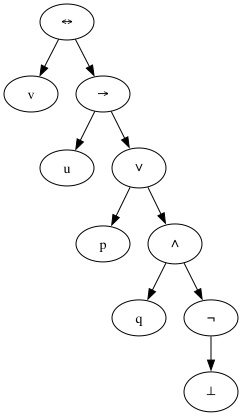

('↔', 'v', ('→', 'u', ('∨', 'p', ('∧', 'q', ('¬', '⊥')))))

In [34]:
test('v ↔ u → p ∨ q ∧ ¬ ⊥')